In [11]:
# ==============================================================================
# CELL 0 & 1: OPUS MASTER BOOTSTRAP (CODESPACE EDITION)
# ==============================================================================
import warnings
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# 1. HYGIENE
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
pd.options.mode.chained_assignment = None 

# 2. CONNECTIVITY
DB_PATH = '/workspaces/pienza/data/pienza.db'
if not os.path.exists(DB_PATH):
    raise FileNotFoundError(f"Database not found at {DB_PATH}")
db_engine = create_engine(f'sqlite:///{DB_PATH}')

# 3. PIENZA CANONICAL PALETTE
PIENZA_PURPLE = "#440154"
PIENZA_TEAL   = "#21918c"
PIENZA_GRAY   = "#555555"
PIENZA_BG     = "#FAFAFA"
PIENZA_TEXT   = "#121212"

# 4. VISUAL THEME
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': PIENZA_BG, 'axes.facecolor': PIENZA_BG, 'text.color': PIENZA_TEXT,
    'xtick.color': '#333333', 'ytick.color': '#333333', 'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0', 'font.family': 'sans-serif',
    'axes.titlecolor': PIENZA_PURPLE, 'axes.titleweight': 'bold'
})

print("✅ Opus Environment LIVE. Path:", DB_PATH)

✅ Opus Environment LIVE. Path: /workspaces/pienza/data/pienza.db


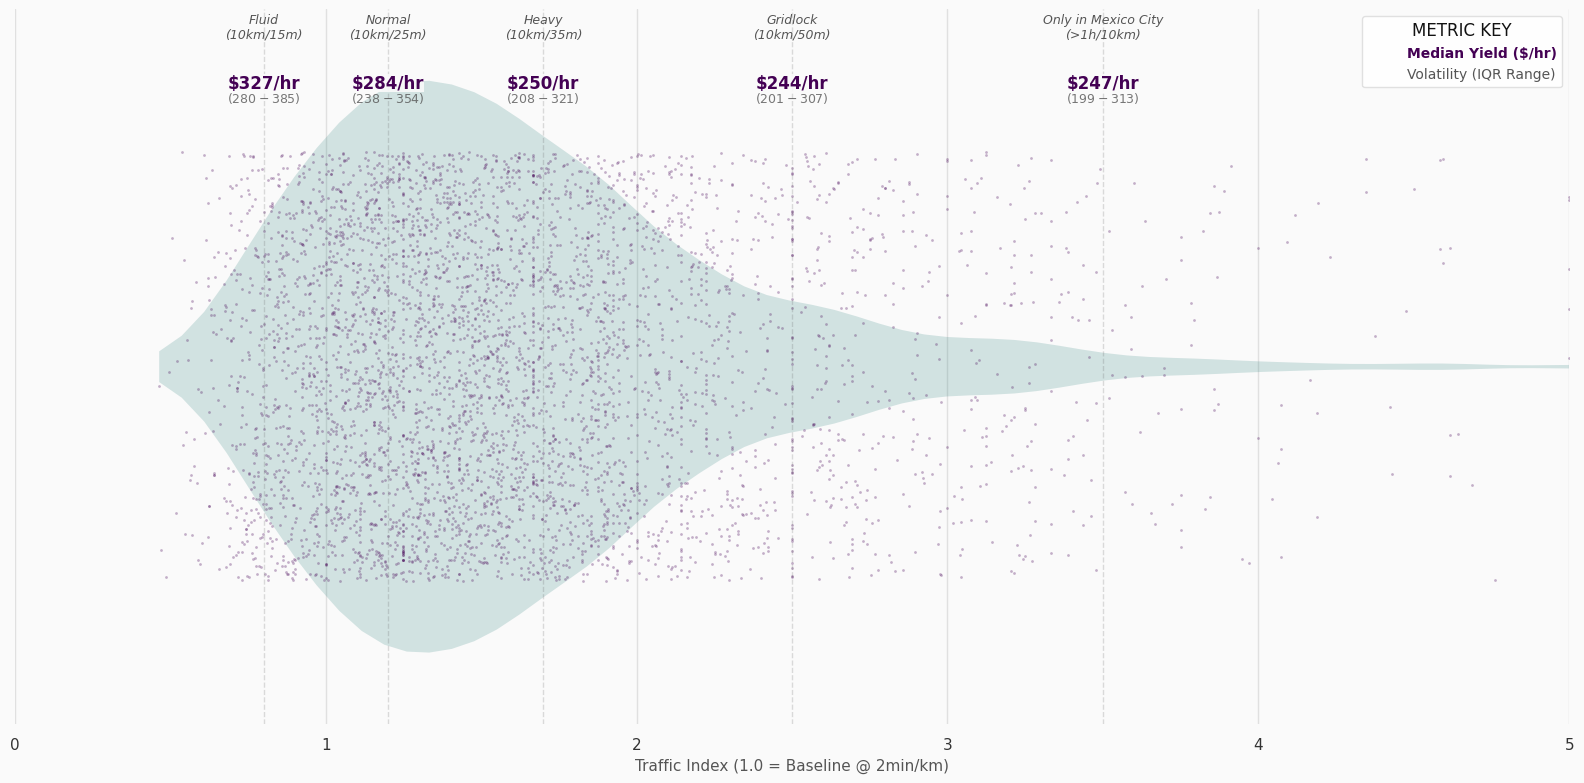

In [12]:
# ==============================================================================
# CELL 13 (FINAL GOLD + LEGEND): THE COST OF FRICTION & VOLATILITY
# ==============================================================================
# Purpose: The definitive visualization of EPH vs Traffic.
#          Includes Median (Efficiency), IQR (Volatility), and an explicit Legend.
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

# 1. PIENZA CANONICAL PALETTE
PIENZA_TEAL = "#21918c"
PIENZA_PURPLE = "#440154"
PIENZA_GRAY = "#555555"
PIENZA_BG = "#FAFAFA"

# 2. LOAD DATA
query = """
SELECT
    traffic_index_base_120,
    eph_direct
FROM v_offers_human
WHERE traffic_index_base_120 IS NOT NULL
  AND traffic_index_base_120 < 10
  AND eph_direct BETWEEN 0 AND 1000
"""
df_traffic = pd.read_sql(query, db_engine)

# 3. CALCULATE ROBUST STATS
bins = [0, 1.0, 1.5, 2.0, 3.0, 10]
labels = ['Fluid', 'Normal', 'Heavy', 'Gridlock', 'CDMX_Only']
df_traffic['traffic_bin'] = pd.cut(df_traffic['traffic_index_base_120'], bins=bins, labels=labels)

stats = df_traffic.groupby('traffic_bin', observed=True)['eph_direct'].agg(
    median='median',
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75)
).to_dict('index')

# 4. PLOTTING
fig, ax = plt.subplots(figsize=(16, 8), facecolor=PIENZA_BG)
ax.set_facecolor(PIENZA_BG)

# --- VIOLIN & STRIP ---
sns.violinplot(
    data=df_traffic, x='traffic_index_base_120', color=PIENZA_TEAL,
    inner=None, alpha=0.2, ax=ax, linewidth=0, cut=0
)
sns.stripplot(
    data=df_traffic, x='traffic_index_base_120',
    color=PIENZA_PURPLE, alpha=0.3, size=2, jitter=0.3, ax=ax, zorder=1
)

# 5. ANNOTATIONS & LEGEND
anchors = [
    (0.8, "Fluid\n(10km/15m)", 'Fluid'),
    (1.2, "Normal\n(10km/25m)", 'Normal'),
    (1.7, "Heavy\n(10km/35m)", 'Heavy'),
    (2.5, "Gridlock\n(10km/50m)", 'Gridlock'),
    (3.5, "Only in Mexico City\n(>1h/10km)", 'CDMX_Only')
]

for x_val, label_text, bin_key in anchors:
    ax.axvline(x_val, color=PIENZA_GRAY, alpha=0.2, linestyle='--', linewidth=1)
    ax.text(x_val, ax.get_ylim()[1]*0.92, label_text, ha='center', fontsize=9, color=PIENZA_GRAY, style='italic')

    if bin_key in stats:
        med = stats[bin_key]['median']
        q1 = stats[bin_key]['q1']
        q3 = stats[bin_key]['q3']

        # HERO METRIC (Purple)
        ax.text(x_val, ax.get_ylim()[1]*0.78, f"${med:,.0f}/hr",
                ha='center', fontsize=12, weight='bold', color=PIENZA_PURPLE,
                bbox=dict(facecolor=PIENZA_BG, alpha=0.9, edgecolor='none', pad=0))

        # SUB-METRIC (Gray)
        ax.text(x_val, ax.get_ylim()[1]*0.74, f"(${q1:,.0f} - ${q3:,.0f})",
                ha='center', fontsize=9, color=PIENZA_GRAY, alpha=0.8)

# --- 6. EXPLICIT LEGEND ---
# We create a custom legend patch to explain the text hierarchy
import matplotlib.lines as mlines

# Create "dummy" handles for the legend
median_handle = mlines.Line2D([], [], color=PIENZA_PURPLE, marker='None',
                              linestyle='None', label='Median Yield ($/hr)')
iqr_handle = mlines.Line2D([], [], color=PIENZA_GRAY, marker='None',
                           linestyle='None', label='Volatility (IQR Range)')

# Add the legend to the upper right
leg = ax.legend(handles=[median_handle, iqr_handle], loc='upper right',
          frameon=True, fontsize=10, title="METRIC KEY")
leg.get_frame().set_edgecolor('#DDDDDD')
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(0.9)

# Color the text in the legend to match the data (Advanced Matplotlib trick)
plt.setp(leg.get_texts()[0], color=PIENZA_PURPLE, weight='bold')
plt.setp(leg.get_texts()[1], color=PIENZA_GRAY)


# Styling
ax.set_xlabel('Traffic Index (1.0 = Baseline @ 2min/km)', fontsize=11, color=PIENZA_GRAY)
ax.set_xlim(0, 5)
sns.despine(left=True, bottom=True)
ax.set_yticks([])
ax.set_ylabel('')

plt.tight_layout()
plt.show()

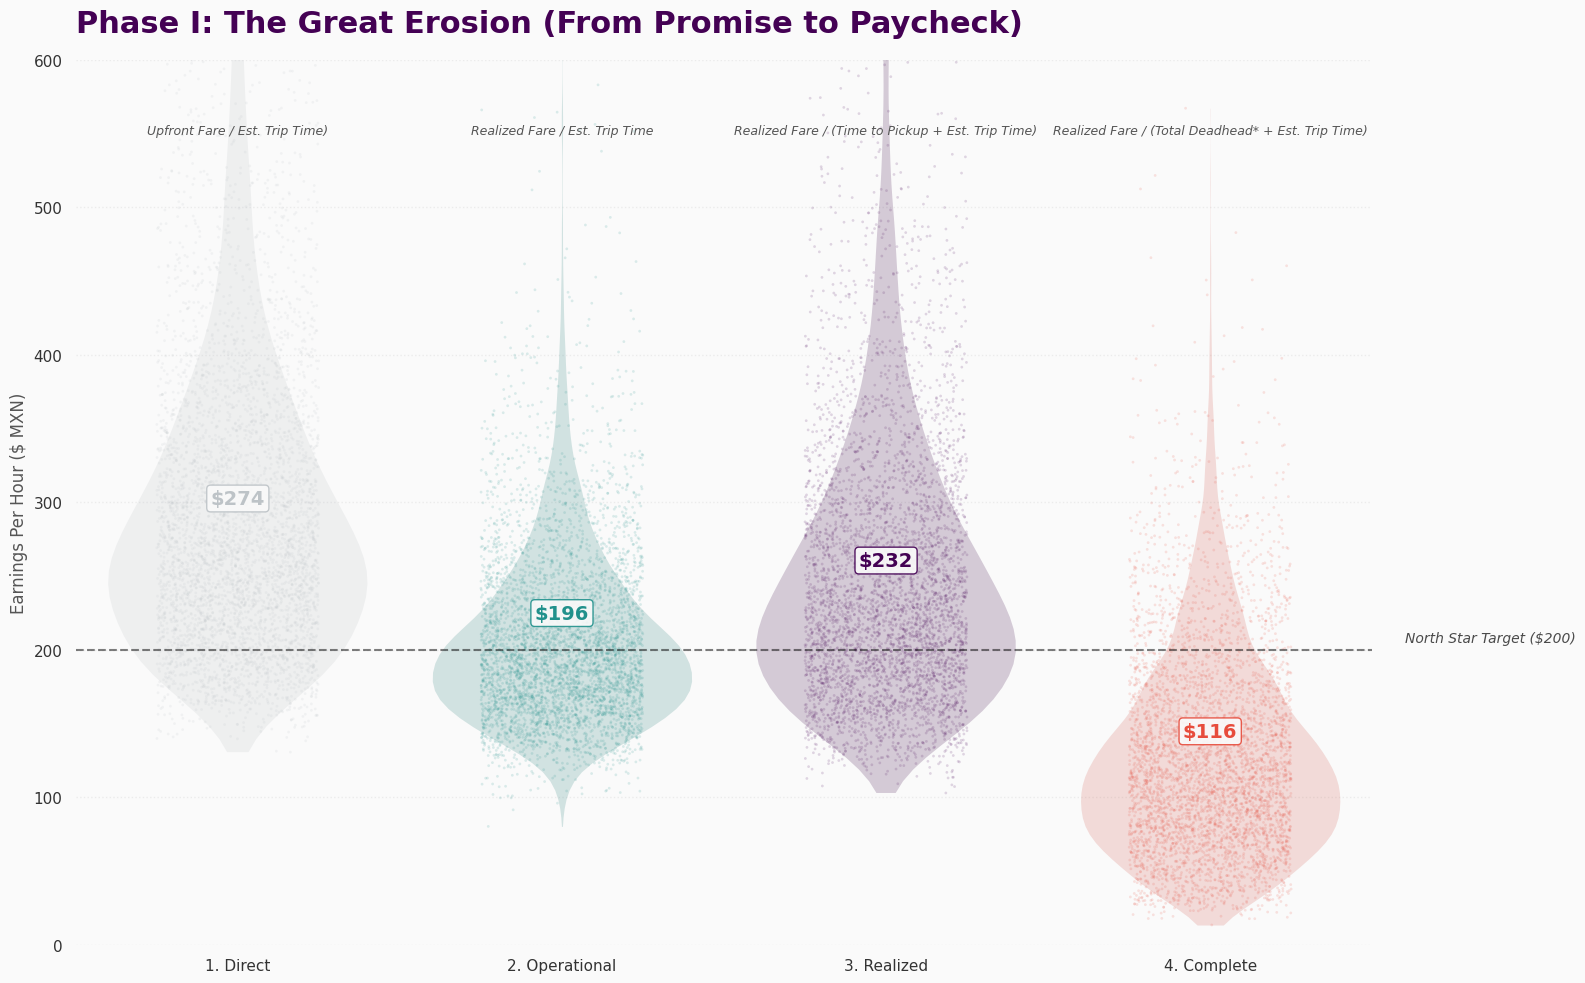


--- 📉 THE EROSION STATISTICS (MEDIAN DROPOFF) ---
Total Value Erosion (Direct -> Complete): -57.6%


In [13]:
# ==============================================================================
# CELL 21 (REFACTORED - PIENZA STYLE): THE GREAT EROSION
# ==============================================================================
# Purpose: Visualizing the decay of value from "Platform Promise" to "Holistic Truth".
#          Style: Pienza Gold (Violin + Strip + Semantic Palette).
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. PIENZA CANONICAL PALETTE & SEMANTIC MAPPING
PIENZA_BG = "#FAFAFA"
PIENZA_GRAY = "#555555"

# Semantic Colors for the Erosion Story
palette_dict = {
    '1. Direct': '#bdc3c7',       # Silver/Gray (The "Paper" Promise)
    '2. Operational': '#21918c',  # Pienza Teal (The Physical Reality)
    '3. Realized': '#440154',     # Pienza Purple (The Bank Reality)
    '4. Complete': '#e74c3c'      # Alizarin Red (The Holistic Truth / Erosion)
}

# 2. LOAD DATA
query = """
SELECT
    eph_direct,
    eph_operational,
    eph_realized_EDA,
    eph_complete_EDA
FROM engineered_features
WHERE eph_direct IS NOT NULL
  AND eph_direct < 1000 -- Sanity check for visualization
"""
df_eph = pd.read_sql(query, db_engine)

# 3. PREPARE DATA FOR PLOTTING (MELT)
# Rename columns for the visual labels
df_eph.columns = ['1. Direct', '2. Operational', '3. Realized', '4. Complete']
df_melted = df_eph.melt(var_name='Metric', value_name='EPH')

# Calculate Medians for Annotations
medians = df_melted.groupby('Metric')['EPH'].median()

# 4. PLOTTING - THE EROSION CASCADE
fig, ax = plt.subplots(figsize=(16, 10), facecolor=PIENZA_BG)
ax.set_facecolor(PIENZA_BG)

# --- A. THE VIOLINS (The Shapes of Reality) ---
sns.violinplot(
    data=df_melted, x='Metric', y='EPH',
    palette=palette_dict,
    inner=None, alpha=0.2, linewidth=0, cut=0, ax=ax
)

# --- B. THE STRIPS (The Particles of Truth) ---
sns.stripplot(
    data=df_melted, x='Metric', y='EPH',
    palette=palette_dict,
    alpha=0.15, size=2, jitter=0.25, zorder=1, ax=ax
)

# 5. ANNOTATIONS & CONTEXT
# The North Star Line ($200 Baseline)
ax.axhline(200, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
ax.text(3.6, 205, "North Star Target ($200)", color='black', fontsize=10, style='italic', alpha=0.7)

# Loop to annotate each Step of the Erosion
for i, metric in enumerate(palette_dict.keys()):
    med_val = medians[metric]
    color = palette_dict[metric]

    # The Median Box
    ax.text(i, med_val + 25, f"${med_val:.0f}",
            ha='center', fontsize=14, weight='bold', color=color,
            bbox=dict(facecolor=PIENZA_BG, alpha=0.9, edgecolor=color, boxstyle='round,pad=0.2'))

    # Context Labels (What does this metric mean?)
    contexts = [
        "Upfront Fare / Est. Trip Time)",
        "Realized Fare / Est. Trip Time",
        "Realized Fare / (Time to Pickup + Est. Trip Time)",
        "Realized Fare / (Total Deadhead* + Est. Trip Time)"
    ]
    ax.text(i, 550, contexts[i], ha='center', fontsize=9, color=PIENZA_GRAY, style='italic')


# 6. STYLING
ax.set_title('Phase I: The Great Erosion (From Promise to Paycheck)',
             fontsize=22, color='#440154', weight='bold', loc='left', pad=20)

ax.set_ylabel('Earnings Per Hour ($ MXN)', fontsize=12, color=PIENZA_GRAY)
ax.set_xlabel('')
ax.set_ylim(0, 600) # Focus on the relevant range

sns.despine(left=True, bottom=True)
ax.grid(axis='y', color='#DDDDDD', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# 7. (OPTIONAL) PRINT STATS FOR PAPER
print("\n--- 📉 THE EROSION STATISTICS (MEDIAN DROPOFF) ---")
erosion_pct = (medians['4. Complete'] - medians['1. Direct']) / medians['1. Direct'] * 100
print(f"Total Value Erosion (Direct -> Complete): {erosion_pct:.1f}%")

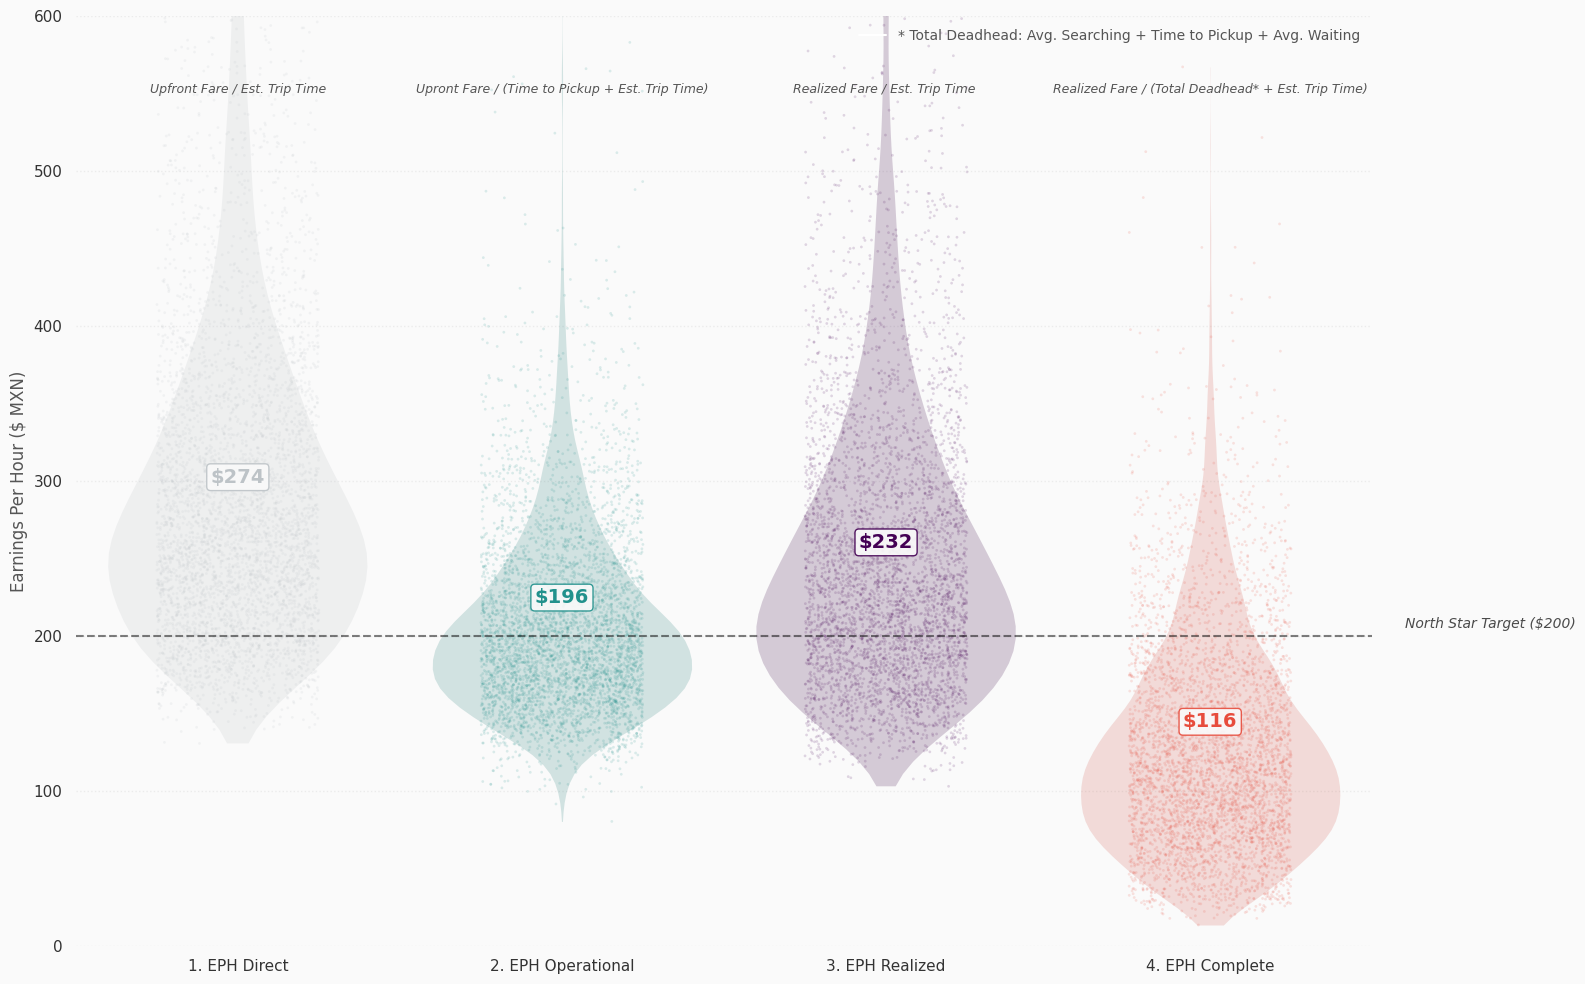


--- 📉 THE EROSION STATISTICS (MEDIAN DROPOFF) ---
Total Value Erosion (Direct -> Complete): -57.6%


In [14]:
# ==============================================================================
# CELL 21 (REFACTORED - PIENZA STYLE): THE GREAT EROSION
# ==============================================================================
# Purpose: Visualizing the decay of value from "Platform Promise" to "Holistic Truth".
#          Style: Pienza Gold (Violin + Strip + Semantic Palette).
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D # Added for legend handle

# 1. PIENZA CANONICAL PALETTE & SEMANTIC MAPPING
PIENZA_BG = "#FAFAFA"
PIENZA_GRAY = "#555555"

# Semantic Colors for the Erosion Story
palette_dict = {
    '1. EPH Direct': '#bdc3c7',       # Silver/Gray (The "Paper" Promise)
    '2. EPH Operational': '#21918c',  # Pienza Teal (The Physical Reality)
    '3. EPH Realized': '#440154',     # Pienza Purple (The Bank Reality)
    '4. EPH Complete': '#e74c3c'      # Alizarin Red (The Holistic Truth / Erosion)
}

# 2. LOAD DATA
query = """
SELECT
    eph_direct,
    eph_operational,
    eph_realized_EDA,
    eph_complete_EDA
FROM engineered_features
WHERE eph_direct IS NOT NULL
  AND eph_direct < 1000 -- Sanity check for visualization
"""
df_eph = pd.read_sql(query, db_engine)

# 3. PREPARE DATA FOR PLOTTING (MELT)
# Rename columns for the visual labels (UPDATED LABELS)
df_eph.columns = ['1. EPH Direct', '2. EPH Operational', '3. EPH Realized', '4. EPH Complete']
df_melted = df_eph.melt(var_name='Metric', value_name='EPH')

# Calculate Medians for Annotations
medians = df_melted.groupby('Metric')['EPH'].median()

# 4. PLOTTING - THE EROSION CASCADE
fig, ax = plt.subplots(figsize=(16, 10), facecolor=PIENZA_BG)
ax.set_facecolor(PIENZA_BG)

# --- A. THE VIOLINS (The Shapes of Reality) ---
sns.violinplot(
    data=df_melted, x='Metric', y='EPH',
    palette=palette_dict,
    inner=None, alpha=0.2, linewidth=0, cut=0, ax=ax
)

# --- B. THE STRIPS (The Particles of Truth) ---
sns.stripplot(
    data=df_melted, x='Metric', y='EPH',
    palette=palette_dict,
    alpha=0.15, size=2, jitter=0.25, zorder=1, ax=ax
)

# 5. ANNOTATIONS & CONTEXT
# The North Star Line ($200 Baseline)
ax.axhline(200, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
ax.text(3.6, 205, "North Star Target ($200)", color='black', fontsize=10, style='italic', alpha=0.7)

# Loop to annotate each Step of the Erosion
for i, metric in enumerate(palette_dict.keys()):
    med_val = medians[metric]
    color = palette_dict[metric]

    # The Median Box
    ax.text(i, med_val + 25, f"${med_val:.0f}",
            ha='center', fontsize=14, weight='bold', color=color,
            bbox=dict(facecolor=PIENZA_BG, alpha=0.9, edgecolor=color, boxstyle='round,pad=0.2'))

    # Context Labels (What does this metric mean?)
    contexts = [
        "Upfront Fare / Est. Trip Time",
        "Upront Fare / (Time to Pickup + Est. Trip Time)",
        "Realized Fare / Est. Trip Time ",
        "Realized Fare / (Total Deadhead* + Est. Trip Time)"
    ]
    ax.text(i, 550, contexts[i], ha='center', fontsize=9, color=PIENZA_GRAY, style='italic')




ax.set_ylabel('Earnings Per Hour ($ MXN)', fontsize=12, color=PIENZA_GRAY)
ax.set_xlabel('')
ax.set_ylim(0, 600) # Focus on the relevant range

# --- 7. LEGEND (Explicit definition for *Total Deadhead) ---
legend_handle = [Line2D([0], [0], color='white', label='* Total Deadhead: Avg. Searching + Time to Pickup + Avg. Waiting')]
ax.legend(handles=legend_handle, loc='upper right', frameon=False, fontsize=10, labelcolor=PIENZA_GRAY)

sns.despine(left=True, bottom=True)
ax.grid(axis='y', color='#DDDDDD', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# 7. (OPTIONAL) PRINT STATS FOR PAPER
print("\n--- 📉 THE EROSION STATISTICS (MEDIAN DROPOFF) ---")
erosion_pct = (medians['4. EPH Complete'] - medians['1. EPH Direct']) / medians['1. EPH Direct'] * 100
print(f"Total Value Erosion (Direct -> Complete): {erosion_pct:.1f}%")

In [15]:
# ==============================================================================
# CELL 22: NORTH STAR FEASIBILITY CHECK (4. COMPLETE)
# ==============================================================================
# Purpose: Quantify the percentage of rides that survive the friction to meet the target.
# ==============================================================================

# 1. DEFINE TARGET
north_star_target = 200
metric_col = '4. EPH Complete' # The column name from the previous dataframe

# 2. PERFORM CALCULATION
# Filter the dataframe 'df_eph' which was created in the previous cell (Cell 21)
# Note: df_eph columns were renamed to ['1. Direct', '2. Operational', '3. Realized', '4. Complete']
rides_below = df_eph[df_eph[metric_col] < north_star_target]
rides_above = df_eph[df_eph[metric_col] >= north_star_target]

total_count = len(df_eph)
pct_below = (len(rides_below) / total_count) * 100
pct_above = (len(rides_above) / total_count) * 100

# 3. PRINT RESULTS
print(f"--- 🎯 NORTH STAR FEASIBILITY REPORT ---")
print(f"Target EPH: ${north_star_target} MXN")
print(f"Metric Analyzed: {metric_col} (Holistic Truth)")
print(f"-" * 40)
print(f"📉 Rides BELOW Target: {pct_below:.2f}%")
print(f"📈 Rides ABOVE Target: {pct_above:.2f}%")

--- 🎯 NORTH STAR FEASIBILITY REPORT ---
Target EPH: $200 MXN
Metric Analyzed: 4. EPH Complete (Holistic Truth)
----------------------------------------
📉 Rides BELOW Target: 83.45%
📈 Rides ABOVE Target: 13.48%


⏳ Calculating Session Efficiency (EPH)...


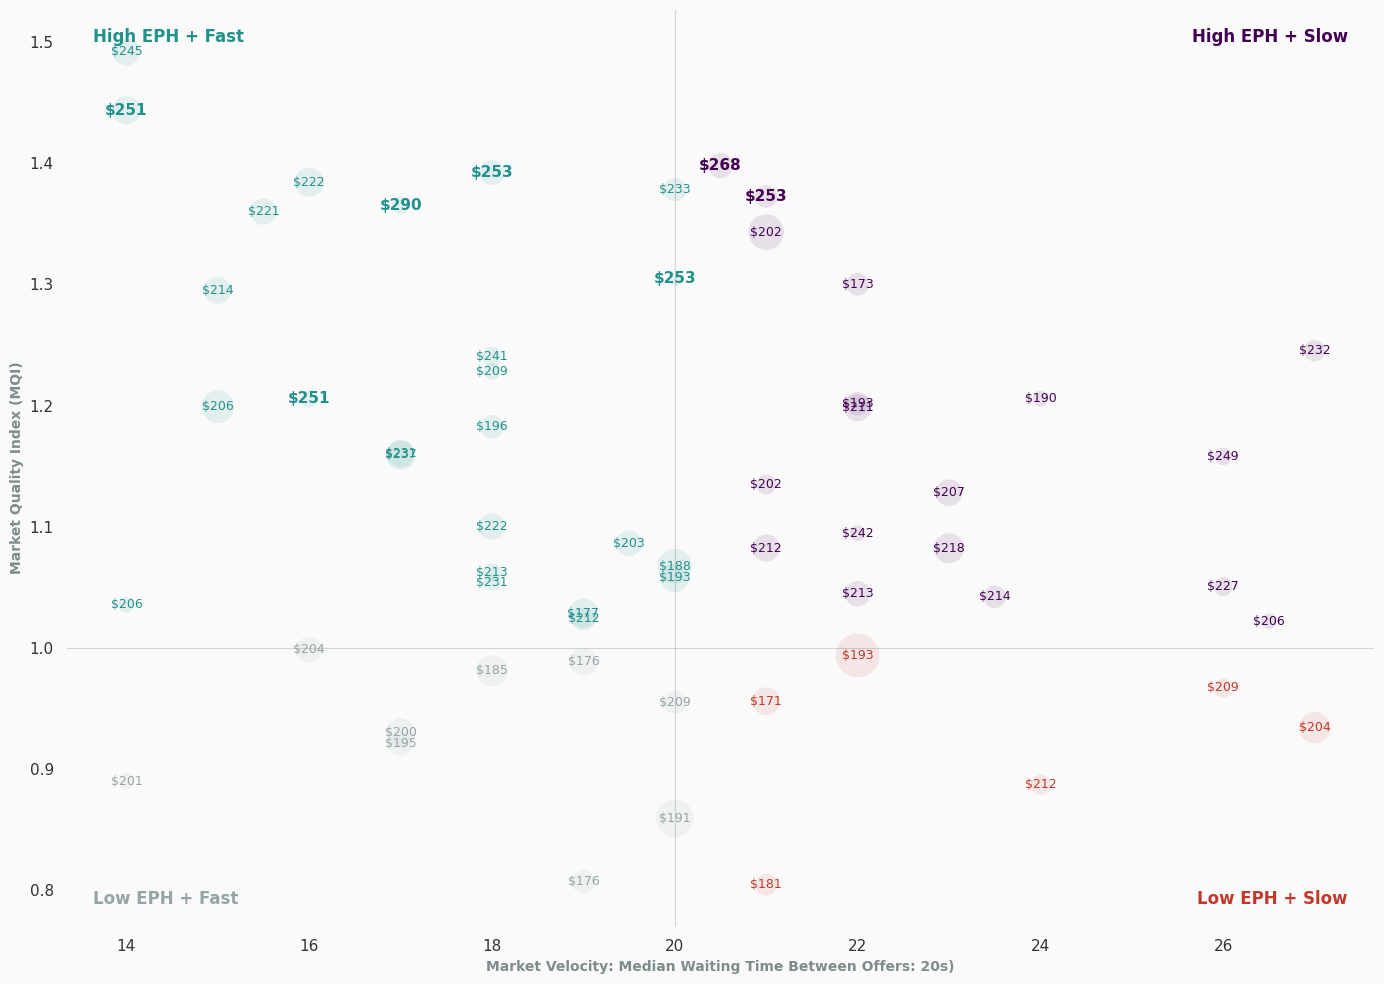


--- ⚡ EFFICIENCY CENSUS ---
Global Average Operational EPH: $209.99/hr

Top 3 Most Efficient Sessions:


,session_fk,Quadrant,avg_eph,offer_count
39,SID0042,Rich / Fast,290.462036,38
11,SID0013,Rich / Slow,267.500417,77
4,SID0006,Rich / Fast,253.330385,23


In [6]:
# ==============================================================================
# CELL 23 (REFACTORED: OPERATIONAL EPH MAP): THE EFFICIENCY TRUTH
# ==============================================================================
# Purpose: Visualizing the "Quality of Speed" per Session.
# Metric:  Average Operational EPH ($/hr) seen in the session.
# Logic:   High EPH confirms that the "Sniper" wait is worth the efficiency gain.
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. PIENZA PROFESSIONAL PALETTE
PIENZA_BG = "#FAFAFA"
COLORS = {
    'Rich / Fast': '#21918c',  # Teal
    'Rich / Slow': '#440154',  # Purple
    'Poor / Fast': '#95a5a6',  # Grey
    'Poor / Slow': '#c0392b'   # Red
}

# 2. DATA INGESTION
print("⏳ Calculating Session Efficiency (EPH)...")
query = """
SELECT
    v.offer_id,
    v.session_fk,
    v.offer_timestamp,
    v.str_product,
    v.str_action,
    v.eph_operational,         -- HERO METRIC: Efficiency ($/hr)
    v.time_since_last_offer as raw_delta,
    ef.eph_realized_EDA
FROM v_offers_human v
JOIN engineered_features ef ON v.offer_id = ef.offer_id_fk
WHERE ef.eph_realized_EDA IS NOT NULL
  AND v.eph_operational > 0    -- Sanity filter
  AND v.eph_operational < 1000 -- Outlier filter for visualization
ORDER BY v.session_fk, v.offer_timestamp
"""
df = pd.read_sql(query, db_engine)

# 3. LOGIC A: SANITIZATION (Clean Wait Time)
df['prev_action'] = df.groupby('session_fk')['str_action'].shift(1)
def sanitize(row):
    if pd.isna(row['prev_action']): return row['raw_delta']
    if 'ACCEPTED' in str(row['prev_action']).upper(): return 0.0
    return row['raw_delta']
df['clean_wait'] = df.apply(sanitize, axis=1)

# 4. LOGIC B: PROTOCOL ALPHA (NORMALIZATION FOR Y-AXIS)
def simplify_category(category_name):
    if pd.isna(category_name): return 'Other'
    cat = str(category_name).lower()
    if 'uberx' in cat: return 'UberX'
    elif 'comfort' in cat or 'business' in cat: return 'Mid-Tier'
    elif 'black' in cat: return 'Black'
    else: return 'Other'

df['simplified_category'] = df['str_product'].apply(simplify_category)
df_core = df[df['simplified_category'].isin(['UberX', 'Mid-Tier', 'Black'])].copy()
global_anchors = df_core.groupby('simplified_category')['eph_realized_EDA'].median().to_dict()
df_core['category_anchor'] = df_core['simplified_category'].map(global_anchors)
df_core['mqi'] = df_core['eph_realized_EDA'] / df_core['category_anchor']

# 5. AGGREGATE SESSION METRICS (EFFICIENCY FOCUSED)
session_stats = df_core.groupby('session_fk').agg(
    velocity_median=('clean_wait', 'median'),
    quality_mean=('mqi', 'mean'),
    offer_count=('offer_id', 'count'),
    avg_eph=('eph_operational', 'mean') # <-- NEW HERO METRIC: Avg Operational EPH
).reset_index()

# 6. DEFINE QUADRANTS
GLOBAL_VELOCITY = session_stats['velocity_median'].median()
GLOBAL_QUALITY = 1.0

def get_quadrant(row):
    is_rich = row['quality_mean'] >= GLOBAL_QUALITY
    is_fast = row['velocity_median'] <= GLOBAL_VELOCITY

    if is_rich and is_fast: return 'Rich / Fast'
    if is_rich and not is_fast: return 'Rich / Slow'
    if not is_rich and is_fast: return 'Poor / Fast'
    return 'Poor / Slow'

session_stats['Quadrant'] = session_stats.apply(get_quadrant, axis=1)

# 7. PLOTTING - THE EFFICIENCY MAP
fig, ax = plt.subplots(figsize=(14, 10), facecolor=PIENZA_BG)
ax.set_facecolor(PIENZA_BG)

# Ghost Bubbles (Context only)
sns.scatterplot(
    data=session_stats,
    x='velocity_median',
    y='quality_mean',
    hue='Quadrant',
    palette=COLORS,
    size='offer_count',
    sizes=(100, 1000),
    alpha=0.10,
    legend=False,
    linewidth=0,
    ax=ax
)

# THE NUMBERS (Average Operational EPH)
for i, row in session_stats.iterrows():
    val = row['avg_eph']
    label = f"${val:.0f}" # e.g. $350

    # Logic: Bold if above $250/hr (High Efficiency)
    weight = 'bold' if val > 250 else 'normal'
    fsize = 11 if val > 250 else 9

    color = COLORS[row['Quadrant']]

    ax.text(
        row['velocity_median'],
        row['quality_mean'],
        label,
        color=color,
        fontsize=fsize,
        weight=weight,
        ha='center',
        va='center'
    )

# The Crosshairs
ax.axvline(GLOBAL_VELOCITY, color='#2c3e50', linestyle='-', linewidth=0.8, alpha=0.2)
ax.axhline(GLOBAL_QUALITY, color='#2c3e50', linestyle='-', linewidth=0.8, alpha=0.2)

# Quadrant Text
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
padding_x = (x_max - x_min) * 0.02
padding_y = (y_max - y_min) * 0.02

ax.text(x_min + padding_x, y_max - padding_y, "High EPH + Fast", fontsize=12, color=COLORS['Rich / Fast'], weight='bold', ha='left', va='top')
ax.text(x_max - padding_x, y_max - padding_y, "High EPH + Slow", fontsize=12, color=COLORS['Rich / Slow'], weight='bold', ha='right', va='top')
ax.text(x_min + padding_x, y_min + padding_y, "Low EPH + Fast", fontsize=12, color=COLORS['Poor / Fast'], weight='bold', ha='left', va='bottom')
ax.text(x_max - padding_x, y_min + padding_y, "Low EPH + Slow", fontsize=12, color=COLORS['Poor / Slow'], weight='bold', ha='right', va='bottom')


ax.set_xlabel(f'Market Velocity: Median Waiting Time Between Offers: {GLOBAL_VELOCITY:.0f}s)', fontsize=10, color='#7f8c8d', weight='bold')
ax.set_ylabel('Market Quality Index (MQI)', fontsize=10, color='#7f8c8d', weight='bold')

sns.despine(left=True, bottom=True)
ax.grid(False)

plt.tight_layout()
plt.show()

# Census
print("\n--- ⚡ EFFICIENCY CENSUS ---")
print(f"Global Average Operational EPH: ${df_core['eph_operational'].mean():.2f}/hr")
print("\nTop 3 Most Efficient Sessions:")
display(session_stats.sort_values('avg_eph', ascending=False).head(3)[['session_fk', 'Quadrant', 'avg_eph', 'offer_count']])

In [16]:
# ==============================================================================
# CELL 24: QUADRANT EFFICIENCY AUDIT (THE NUMERICAL PROOF)
# ==============================================================================
# Purpose: Quantify the exact EPH advantage of the "Sniper" strategy.
#          Compares the average Operational Efficiency ($/hr) across regimes.
# ==============================================================================

if 'session_stats' in locals():
    print("--- 📊 OPERATIONAL EPH BY QUADRANT (The Bottom Line) ---")

    # 1. Group by Quadrant and Calculate Stats
    quadrant_efficiency = session_stats.groupby('Quadrant').agg(
        Average_Operational_EPH=('avg_eph', 'mean'),
        Min_EPH=('avg_eph', 'min'),
        Max_EPH=('avg_eph', 'max'),
        Session_Count=('session_fk', 'count')
    ).sort_values('Average_Operational_EPH', ascending=False)

    # 2. Add a "Lift" column (Percentage vs. The Grind)
    try:
        grind_baseline = quadrant_efficiency.loc['Poor / Fast', 'Average_Operational_EPH']
        quadrant_efficiency['Efficiency_Gain'] = (
            (quadrant_efficiency['Average_Operational_EPH'] - grind_baseline) / grind_baseline
        ) * 100
    except KeyError:
        quadrant_efficiency['Efficiency_Gain'] = 0.0

    # 3. Display Formatted Table
    # Styling for impact
    def highlight_sniper(s):
        is_sniper = s.name == 'Rich / Slow'
        return ['background-color: #440154; color: white; font-weight: bold' if is_sniper else '' for _ in s]

    display(quadrant_efficiency.style.apply(highlight_sniper, axis=1)
            .format({
                'Average_Operational_EPH': '${:,.2f}/hr',
                'Min_EPH': '${:,.2f}',
                'Max_EPH': '${:,.2f}',
                'Efficiency_Gain': '+{:,.1f}%'
            })
            .set_caption("Efficiency Audit: Why Patience Pays Off")
    )

    # 4. Print The Narrative Conclusion
    try:
        sniper_eph = quadrant_efficiency.loc['Rich / Slow', 'Average_Operational_EPH']
        grind_eph = quadrant_efficiency.loc['Poor / Fast', 'Average_Operational_EPH']
        premium = ((sniper_eph - grind_eph) / grind_eph) * 100

        print(f"\n🚀 THE SNIPER PREMIUM:")
        print(f"waiting for quality (Rich/Slow) yields a +{premium:.1f}% higher hourly efficiency")
        print(f"compared to chasing volume in 'The Grind' (Poor/Fast).")
        print(f"\nThis confirms: Movement != Money.")
    except KeyError:
        pass

else:
    print("🔴 'session_stats' dataframe not found. Please run Cell 23 first.")

--- 📊 OPERATIONAL EPH BY QUADRANT (The Bottom Line) ---


,Average_Operational_EPH,Min_EPH,Max_EPH,Session_Count,Efficiency_Gain
Quadrant,,,,,
Rich / Fast,$223.98/hr,$177.39,$290.46,25,+16.1%
Rich / Slow,$217.32/hr,$172.89,$267.50,18,+12.6%
Poor / Slow,$194.96/hr,$171.42,$211.66,6,+1.1%
Poor / Fast,$192.93/hr,$175.79,$208.68,9,+0.0%



🚀 THE SNIPER PREMIUM:
waiting for quality (Rich/Slow) yields a +12.6% higher hourly efficiency
compared to chasing volume in 'The Grind' (Poor/Fast).

This confirms: Movement != Money.


⏳ Loading Decision Economics data...
✅ Data Loaded: Global N=4762 | Economic N=2160


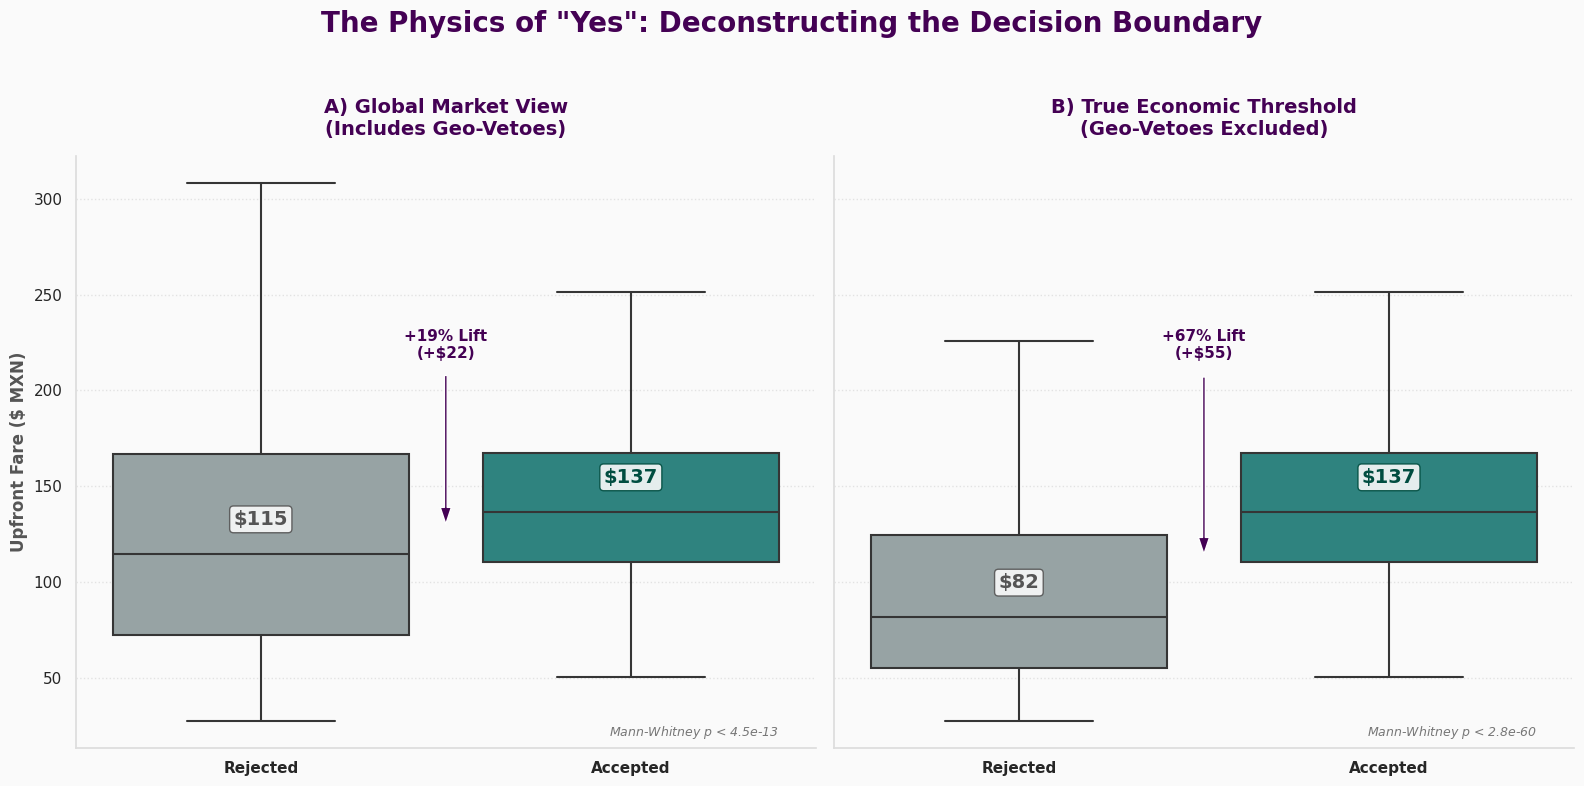

In [17]:
# ==============================================================================
# CELL 15 (CONSOLIDATED): THE PHYSICS OF "YES" (FINANCIAL THRESHOLD ANALYSIS)
# ==============================================================================
# Purpose: Comparative analysis of the Agent's decision boundary.
#          Left: Global Market (Raw).
#          Right: True Economic Threshold (Geospatial Vetoes Removed).
# Style:   Pienza Sober (Teal/Purple/Grey).
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. PIENZA SOBER PALETTE & THEME
PIENZA_BG = '#FAFAFA'
PIENZA_TEXT = '#121212'
PIENZA_PURPLE = '#440154' # Wealth / Headers
PIENZA_TEAL = '#21918c'   # Signal / Accept
PIENZA_GREY = '#95a5a6'   # Noise / Reject

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': PIENZA_BG,
    'axes.facecolor': PIENZA_BG,
    'text.color': PIENZA_TEXT,
    'axes.edgecolor': '#DDDDDD',
    'font.family': 'sans-serif'
})

# 2. DATA INGESTION
print("⏳ Loading Decision Economics data...")
query = """
SELECT
    upfront_fare,
    str_action,
    str_reason
FROM v_offers_human
WHERE upfront_fare IS NOT NULL
  AND upfront_fare < 600 -- Outlier filter for cleaner visualization
  AND str_action IN ('accepted', 'reject')
"""
df_raw = pd.read_sql(query, db_engine)

# 3. DATA PROCESSING
# Dataset A: Global (Raw)
df_global = df_raw.copy()

# Dataset B: Pure Economic (Geo-Vetoes Removed)
geo_vetoes = ['dropoff_non_operational', 'dropoff_proxy']
df_economic = df_raw[~df_raw['str_reason'].isin(geo_vetoes)].copy()

print(f"✅ Data Loaded: Global N={len(df_global)} | Economic N={len(df_economic)}")

# 4. PLOTTING CONFIGURATION
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
fig.suptitle('The Physics of "Yes": Deconstructing the Decision Boundary',
             fontsize=20, color=PIENZA_PURPLE, weight='bold', y=0.98)

# Shared Palette
palette = {'reject': PIENZA_GREY, 'accepted': PIENZA_TEAL}

# --- HELPER FUNCTION FOR PLOTTING ---
def plot_decision_boundary(df, ax, title):
    # Boxplot
    sns.boxplot(x='str_action', y='upfront_fare', data=df, ax=ax,
                palette=palette, showfliers=False, order=['reject', 'accepted'],
                linewidth=1.5)

    # Statistics
    accepted = df[df['str_action'] == 'accepted']['upfront_fare']
    rejected = df[df['str_action'] == 'reject']['upfront_fare']

    med_acc = accepted.median()
    med_rej = rejected.median()
    delta = med_acc - med_rej
    lift = (delta / med_rej) * 100
    u_stat, p_val = stats.mannwhitneyu(accepted, rejected)

    # Annotations (Medians)
    for i, action in enumerate(['reject', 'accepted']):
        val = med_rej if action == 'reject' else med_acc
        color = '#555555' if action == 'reject' else '#004d40' # Darker teal for text
        ax.text(i, val + 15, f"${val:.0f}", ha='center', fontweight='bold', color=color, fontsize=14,
                bbox=dict(facecolor=PIENZA_BG, edgecolor=color, boxstyle='round,pad=0.2', alpha=0.9))

    # Lift Arrow
    mid_x = 0.5
    mid_y = (med_acc + med_rej) / 2
    ax.annotate(f'+{lift:.0f}% Lift\n(+${delta:.0f})',
                xy=(mid_x, mid_y),
                xytext=(mid_x, med_acc + 80),
                arrowprops=dict(facecolor=PIENZA_PURPLE, shrink=0.05, width=2, headwidth=8),
                ha='center', fontweight='bold', color=PIENZA_PURPLE, fontsize=11,
                bbox=dict(facecolor=PIENZA_BG, edgecolor='none', alpha=0.8))

    # Styling
    ax.set_title(title, fontsize=14, color=PIENZA_PURPLE, weight='bold', pad=15)
    ax.set_xlabel('')
    ax.set_ylabel('Upfront Fare ($ MXN)' if ax == axes[0] else '', fontweight='bold', color='#555')
    ax.set_xticklabels(['Rejected', 'Accepted'], fontweight='bold', fontsize=11)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

    # Statistical Footer inside plot
    stats_text = f"Mann-Whitney $p$ < {p_val:.1e}" if p_val < 0.001 else f"MW $p$={p_val:.3f}"
    ax.text(0.95, 0.02, stats_text, transform=ax.transAxes, ha='right', fontsize=9, color='#777', style='italic')

# --- EXECUTE PLOTS ---
plot_decision_boundary(df_global, axes[0], "A) Global Market View\n(Includes Geo-Vetoes)")
plot_decision_boundary(df_economic, axes[1], "B) True Economic Threshold\n(Geo-Vetoes Excluded)")

sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

⏳ Loading Taxonomy data...


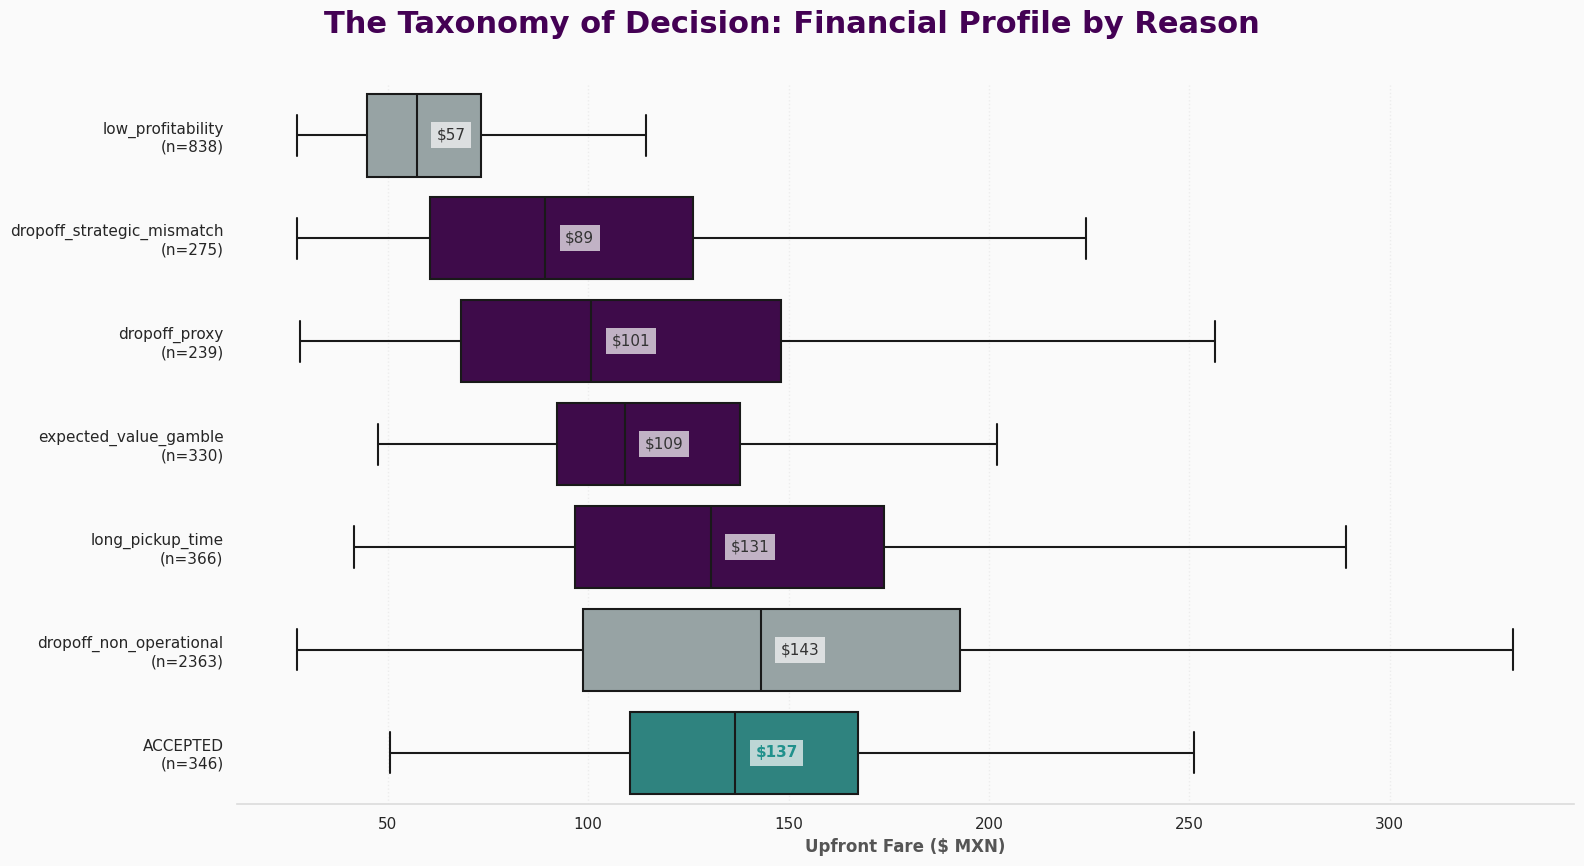

In [18]:
# ==============================================================================
# CELL 16 (FINAL TECHNICAL): THE TAXONOMY OF DECISION (ACCEPTED vs. REJECTION)
# ==============================================================================
# Purpose: Compare the financial profile of the "Yes" against specific types of "No".
# Logic:   1. Filters out System Logic (Ghost offers).
#          2. Integrates 'ACCEPTED' offers as a benchmark class.
#          3. Orders by Median Fare, but forces ACCEPTED to the far right.
# Style:   Pienza Sober (Teal for Signal, Magma for Noise).
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PIENZA VISUAL THEME
sns.set_theme(style="whitegrid")
PIENZA_BG = '#FAFAFA'
PIENZA_PURPLE = '#440154'
PIENZA_TEAL = '#21918c'

plt.rcParams.update({
    'figure.facecolor': PIENZA_BG,
    'axes.facecolor': PIENZA_BG,
    'text.color': '#121212',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif'
})

# 2. LOAD DATA (Including Action for the "Accepted" class)
print("⏳ Loading Taxonomy data...")
query = """
SELECT
    upfront_fare,
    str_reason,
    str_action
FROM v_offers_human
WHERE upfront_fare IS NOT NULL
  AND upfront_fare < 600 -- Outlier filter
"""
df_raw = pd.read_sql(query, db_engine)

# 3. DATA PROCESSING & LABELLING
# Step A: Filter out System Logic artifacts
df_clean = df_raw[df_raw['str_reason'] != 'system_logic_failure'].copy()

# Step B: Label Assignment (Keep original snake_case)
def assign_label(row):
    # Priority 1: Was it accepted?
    if row['str_action'] == 'accepted':
        return 'ACCEPTED'

    # Priority 2: Return the original rejection reason
    if pd.notna(row['str_reason']):
        return row['str_reason']

    # Fallback
    return 'unknown_reject'

df_clean['Base_Label'] = df_clean.apply(assign_label, axis=1)

# Step C: Add Counts (N) to labels for context
counts = df_clean['Base_Label'].value_counts()
df_clean['Final_Label'] = df_clean['Base_Label'].apply(lambda x: f"{x}\n(n={counts[x]})")

# 4. ORDERING LOGIC (ACCEPTED LAST)
# First, sort rejections by median fare (ascending)
rejections = df_clean[df_clean['Base_Label'] != 'ACCEPTED']
order_rejections = rejections.groupby('Final_Label')['upfront_fare'].median().sort_values(ascending=True).index.tolist()

# Then, get the label for ACCEPTED
label_accepted = df_clean[df_clean['Base_Label'] == 'ACCEPTED']['Final_Label'].unique()[0]

# Combine: Rejections first, Accepted last
final_order = order_rejections + [label_accepted]

# 5. PALETTE GENERATION
# Logic: Highlight "ACCEPTED" in Pienza Teal, others in a muted scale
palette_dict = {}
for label in final_order:
    if "ACCEPTED" in label:
        palette_dict[label] = PIENZA_TEAL # The Signal
    elif "non_operational" in label or "low_profitability" in label:
        palette_dict[label] = '#95a5a6'   # The Noise (Grey)
    else:
        palette_dict[label] = PIENZA_PURPLE # Strategic Rejections (Purple)

# 6. PLOTTING
fig, ax = plt.subplots(figsize=(16, 9))
fig.suptitle('The Taxonomy of Decision: Financial Profile by Reason',
             fontsize=22, color=PIENZA_PURPLE, weight='bold', y=0.96)

# Boxplot
sns.boxplot(x='upfront_fare', y='Final_Label', data=df_clean, order=final_order, ax=ax,
            palette=palette_dict, showfliers=False, linewidth=1.5)

# Styling
ax.set_xlabel("Upfront Fare ($ MXN)", fontweight='bold', color='#555')
ax.set_ylabel("")
ax.grid(axis='x', linestyle=':', alpha=0.5)

# Annotate Medians
medians = df_clean.groupby('Final_Label')['upfront_fare'].median()
for i, label in enumerate(final_order):
    val = medians[label]
    # Dynamic text color
    text_color = PIENZA_TEAL if "ACCEPTED" in label else '#333'
    weight = 'bold' if "ACCEPTED" in label else 'normal'

    ax.text(val + 5, i, f"${val:.0f}", ha='left', va='center',
            fontweight=weight, color=text_color, fontsize=11,
            bbox=dict(facecolor=PIENZA_BG, edgecolor='none', alpha=0.7))

sns.despine(left=True, bottom=False)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

⏳ Loading Heuristic Flags data...


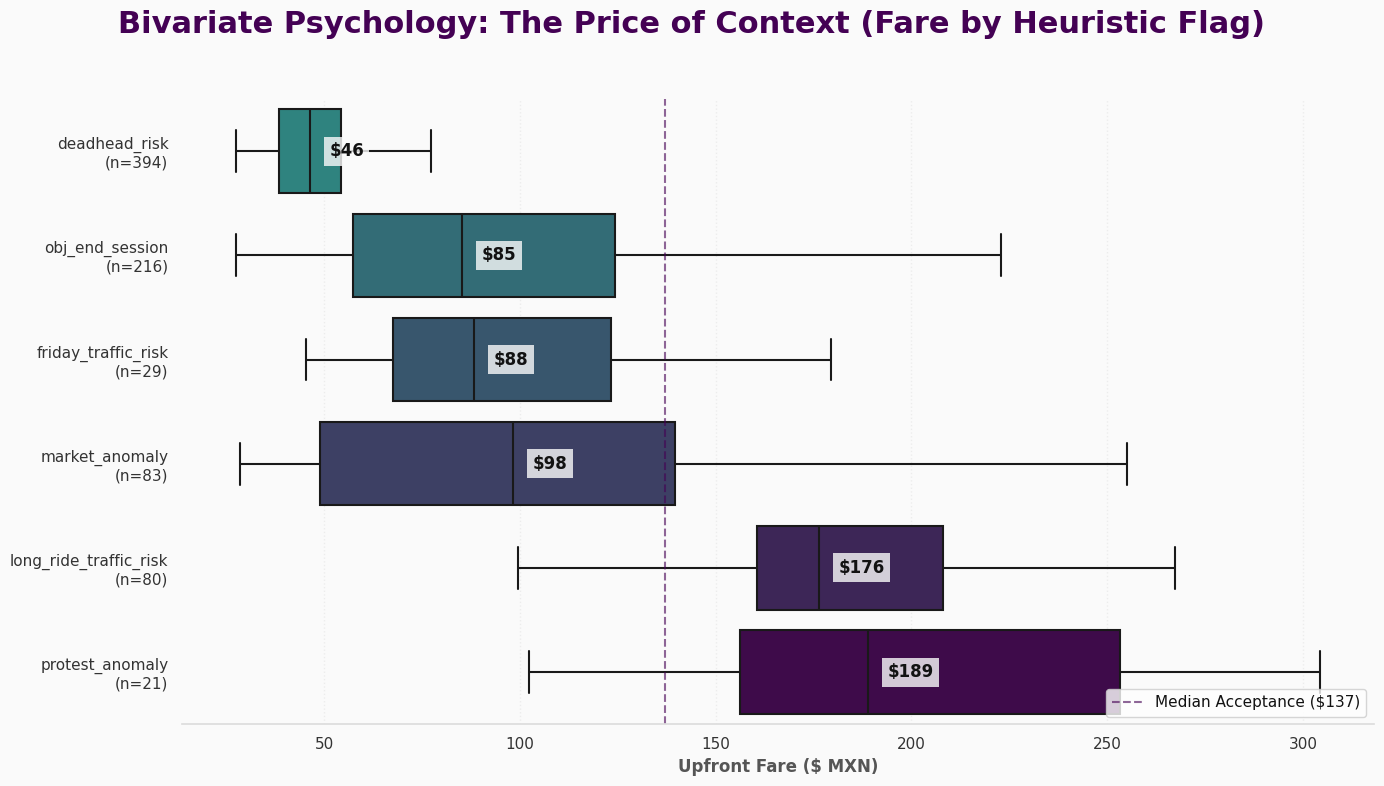

In [19]:
# ==============================================================================
# CELL 17.5 (PIENZA REFACTORED): PSYCHOLOGY TRI-TIER SPLIT (FLAG FARE PROFILE)
# ==============================================================================
# Purpose: To analyze the financial profile of each HEURISTIC FLAG.
#          Quantifies the economic impact of contextual factors (La Naranja).
# Palette: Pienza Sober (Purple #440154 / Teal #21918c)
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. APPLY PIENZA VISUAL CANON
PIENZA_PURPLE = '#440154'
PIENZA_TEAL   = '#21918c'
PIENZA_BG     = '#FAFAFA'
PIENZA_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': PIENZA_BG,
    'axes.facecolor': PIENZA_BG,
    'text.color': PIENZA_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif'
})

# 2. LOAD DATA (Exploding the Many-to-Many Table)
print("⏳ Loading Heuristic Flags data...")
query = """
SELECT
    o.upfront_fare,
    hf.heuristic_flag_description
FROM heuristic_flag_offers hfo
JOIN offers o ON hfo.offers_offer_id = o.offer_id
JOIN heuristic_flag hf ON hfo.heuristic_flag_heuristic_flag_id = hf.heuristic_flag_id
WHERE o.upfront_fare IS NOT NULL
"""
df_flag = pd.read_sql(query, db_engine)

# 3. FILTER & COUNT
flag_counts = df_flag['heuristic_flag_description'].value_counts()
min_count = 10
valid_flags = flag_counts[flag_counts >= min_count].index
df_plot = df_flag[df_flag['heuristic_flag_description'].isin(valid_flags)].copy()

# Create Label with N for volume context
df_plot['Label_N'] = df_plot['heuristic_flag_description'].apply(lambda x: f"{x}\n(n={flag_counts[x]})")

# Filter outliers for visualization (< $600)
df_plot = df_plot[df_plot['upfront_fare'] < 600]

# 4. SORTING (BY MEDIAN FARE)
order = df_plot.groupby('Label_N')['upfront_fare'].median().sort_values().index

# 5. PLOTTING CONFIGURATION
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle('Bivariate Psychology: The Price of Context (Fare by Heuristic Flag)',
             fontsize=22, color=PIENZA_PURPLE, weight='bold', y=0.98)

# --- BOXPLOT ---
# Using a custom Pienza-aligned palette (Teal to Purple transition)
sns.boxplot(x='upfront_fare', y='Label_N', data=df_plot, order=order, ax=ax,
            palette=sns.color_palette(f"blend:{PIENZA_TEAL},{PIENZA_PURPLE}", len(order)),
            showfliers=False, linewidth=1.5)

ax.set_xlabel("Upfront Fare ($ MXN)", fontweight='bold', color='#555')
ax.set_ylabel("")
ax.grid(axis='x', linestyle=':', alpha=0.5)

# Annotate Medians with bold labels
medians = df_plot.groupby('Label_N')['upfront_fare'].median()
for i, label in enumerate(order):
    val = medians[label]
    ax.text(val + 5, i, f"${val:.0f}", ha='left', va='center', fontweight='bold', color=PIENZA_TEXT,
            bbox=dict(facecolor=PIENZA_BG, edgecolor='none', alpha=0.8))

# Reference Line (Global Acceptance Median) - Benchmark from Phase 3A Census
# Note: The $137 baseline is derived from accepted trip analysis [cite: 663]
ax.axvline(137, color=PIENZA_PURPLE, linestyle='--', alpha=0.6, label='Median Acceptance ($137)')
ax.legend(loc='lower right', frameon=True, facecolor='white')

sns.despine(left=True, bottom=False)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()